In [1]:
# ============================================
# CELL 1 - Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import mlflow
import mlflow.pytorch
import mlflow.sklearn
import pickle
import os
import json
import warnings
warnings.filterwarnings('ignore')

from mlflow.tracking import MlflowClient
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print(f"✅ MLflow version: {mlflow.__version__}")
print("✅ All imports done!")

# Set MLflow tracking URI
mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = MlflowClient()
print("✅ MLflow client ready!")

✅ MLflow version: 3.11.1
✅ All imports done!
✅ MLflow client ready!


In [2]:
# ============================================
# CELL 2 - Load All Saved Data
# ============================================

# Load sequences
X_train = np.load('data/processed/X_train.npy')
y_train = np.load('data/processed/y_train.npy')
X_test  = np.load('data/processed/X_test.npy')
y_test  = np.load('data/processed/y_test.npy')

# Load scalers
with open('data/processed/rul_scaler.pkl', 'rb') as f:
    rul_scaler = pickle.load(f)

with open('data/processed/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"✅ Data loaded!")
print(f"📊 X_train : {X_train.shape}")
print(f"📊 X_test  : {X_test.shape}")
print(f"📊 Features: {len(feature_cols)}")
print(f"🖥️  Device  : {device}")

✅ Data loaded!
📊 X_train : (17731, 30, 18)
📊 X_test  : (10196, 30, 18)
📊 Features: 18
🖥️  Device  : cpu


In [3]:
# ============================================
# CELL 3 - Define Model Variants
# ============================================

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        attn_weights = torch.softmax(
            self.attention(lstm_out), dim=1
        )
        context = (attn_weights * lstm_out).sum(dim=1)
        return context, attn_weights

class LSTMWithAttention(nn.Module):
    def __init__(self, input_dim,
                 hidden_dim=64,
                 num_layers=2,
                 dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.attention = AttentionLayer(hidden_dim * 2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _        = self.lstm(x)
        out           = self.dropout(out)
        context, attn = self.attention(out)
        return self.fc(context).squeeze(-1), attn

# Model variants to compare
MODEL_VARIANTS = [
    {
        'name'      : 'LSTM_Small',
        'hidden_dim': 32,
        'num_layers': 1,
        'dropout'   : 0.1,
        'lr'        : 0.001,
        'epochs'    : 15
    },
    {
        'name'      : 'LSTM_Medium',
        'hidden_dim': 64,
        'num_layers': 2,
        'dropout'   : 0.2,
        'lr'        : 0.001,
        'epochs'    : 15
    },
    {
        'name'      : 'LSTM_Large',
        'hidden_dim': 128,
        'num_layers': 2,
        'dropout'   : 0.3,
        'lr'        : 0.0005,
        'epochs'    : 15
    },
    {
        'name'      : 'LSTM_Deep',
        'hidden_dim': 64,
        'num_layers': 3,
        'dropout'   : 0.2,
        'lr'        : 0.001,
        'epochs'    : 15
    }
]

print(f"✅ {len(MODEL_VARIANTS)} model variants defined!")
for v in MODEL_VARIANTS:
    print(f"   📊 {v['name']:15s} → "
          f"hidden={v['hidden_dim']}, "
          f"layers={v['num_layers']}")

✅ 4 model variants defined!
   📊 LSTM_Small      → hidden=32, layers=1
   📊 LSTM_Medium     → hidden=64, layers=2
   📊 LSTM_Large      → hidden=128, layers=2
   📊 LSTM_Deep       → hidden=64, layers=3


In [4]:
# ============================================
# CELL 4 - Training Helper Functions
# ============================================
from torch.utils.data import (
    Dataset, DataLoader,
    TensorDataset, random_split
)

class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def get_dataloaders(X_train, y_train,
                    X_test, y_test,
                    batch_size=64):
    full    = RULDataset(X_train, y_train)
    val_sz  = int(len(full) * 0.2)
    tr_sz   = len(full) - val_sz
    tr, val = random_split(full, [tr_sz, val_sz])

    return (
        DataLoader(tr,  batch_size=batch_size,
                   shuffle=True),
        DataLoader(val, batch_size=batch_size,
                   shuffle=False),
        DataLoader(RULDataset(X_test, y_test),
                   batch_size=batch_size,
                   shuffle=False)
    )

def train_and_evaluate(model, train_loader,
                       val_loader, test_loader,
                       epochs=15, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr,
        weight_decay=1e-5
    )
    scheduler = torch.optim.lr_scheduler\
                    .ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    best_val    = float('inf')
    best_state  = None
    train_losses= []
    val_losses  = []

    for epoch in range(epochs):
        # Train
        model.train()
        t_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            pred, _ = model(bx)
            loss    = criterion(pred, by)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(), 1.0
            )
            optimizer.step()
            t_loss += loss.item()

        # Validate
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                pred, _= model(bx)
                v_loss += criterion(pred, by).item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        train_losses.append(avg_t)
        val_losses.append(avg_v)
        scheduler.step(avg_v)

        if avg_v < best_val:
            best_val   = avg_v
            best_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }

    # Load best weights
    model.load_state_dict(best_state)

    # Evaluate on test
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            p, _ = model(bx)
            preds.extend(p.cpu().numpy())
            targets.extend(by.numpy())

    preds   = np.array(preds)
    targets = np.array(targets)

    # Inverse transform
    p_actual = rul_scaler.inverse_transform(
        preds.reshape(-1,1)
    ).flatten()
    t_actual = rul_scaler.inverse_transform(
        targets.reshape(-1,1)
    ).flatten()

    mae  = mean_absolute_error(t_actual, p_actual)
    rmse = np.sqrt(mean_squared_error(
        t_actual, p_actual
    ))
    r2   = r2_score(t_actual, p_actual)
    mape = np.mean(
        np.abs((t_actual - p_actual) /
               (t_actual + 1e-8))
    ) * 100

    return {
        'mae'         : mae,
        'rmse'        : rmse,
        'r2'          : r2,
        'mape'        : mape,
        'best_val_loss': best_val,
        'train_losses': train_losses,
        'val_losses'  : val_losses,
        'predictions' : p_actual,
        'targets'     : t_actual
    }

print("✅ Training helpers ready!")

✅ Training helpers ready!


In [5]:
# ============================================
# CELL 5 - Run All Model Variants
# ============================================

mlflow.set_experiment("rul_model_comparison")

train_loader, val_loader, test_loader = \
    get_dataloaders(
        X_train, y_train,
        X_test,  y_test
    )

input_dim    = X_train.shape[2]
all_results  = []

print("🔄 Training all model variants...")
print("="*55)

for variant in MODEL_VARIANTS:
    print(f"\n📊 Training: {variant['name']}")

    # Build model
    model = LSTMWithAttention(
        input_dim=input_dim,
        hidden_dim=variant['hidden_dim'],
        num_layers=variant['num_layers'],
        dropout=variant['dropout']
    ).to(device)

    # Train & evaluate
    with mlflow.start_run(
        run_name=variant['name']
    ):
        # Log parameters
        mlflow.log_params({
            'model_name' : variant['name'],
            'hidden_dim' : variant['hidden_dim'],
            'num_layers' : variant['num_layers'],
            'dropout'    : variant['dropout'],
            'lr'         : variant['lr'],
            'epochs'     : variant['epochs'],
            'input_dim'  : input_dim,
            'seq_len'    : X_train.shape[1]
        })

        # Train
        results = train_and_evaluate(
            model,
            train_loader,
            val_loader,
            test_loader,
            epochs=variant['epochs'],
            lr=variant['lr']
        )

        # Log metrics
        mlflow.log_metrics({
            'test_mae'     : results['mae'],
            'test_rmse'    : results['rmse'],
            'test_r2'      : results['r2'],
            'test_mape'    : results['mape'],
            'best_val_loss': results['best_val_loss']
        })

        # Log model
        mlflow.pytorch.log_model(
            model, variant['name']
        )

        results['name']   = variant['name']
        results['variant']= variant
        all_results.append(results)

        print(f"   MAE : {results['mae']:.4f}")
        print(f"   MAPE: {results['mape']:.2f}%")
        print(f"   R²  : {results['r2']:.4f}")

print("\n✅ All variants trained!")

2026/04/24 11:00:07 INFO mlflow.tracking.fluent: Experiment with name 'rul_model_comparison' does not exist. Creating a new experiment.


🔄 Training all model variants...

📊 Training: LSTM_Small


2026/04/24 11:02:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 11:02:24 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


   MAE : 43.5707
   MAPE: 7520238592.00%
   R²  : -0.8872

📊 Training: LSTM_Medium


2026/04/24 11:10:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 11:10:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


   MAE : 43.3619
   MAPE: 7586668032.00%
   R²  : -0.8667

📊 Training: LSTM_Large


2026/04/24 11:26:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 11:26:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


   MAE : 42.0151
   MAPE: 7392644608.00%
   R²  : -0.7657

📊 Training: LSTM_Deep


2026/04/24 11:36:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 11:36:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


   MAE : 43.7817
   MAPE: 7591841792.00%
   R²  : -0.9174

✅ All variants trained!


In [6]:
# ============================================
# CELL 6 - Compare All Results
# ============================================

comparison_df = pd.DataFrame([{
    'Model'     : r['name'],
    'MAE'       : round(r['mae'],   4),
    'RMSE'      : round(r['rmse'],  4),
    'R²'        : round(r['r2'],    4),
    'MAPE (%)'  : round(r['mape'],  2),
    'Val Loss'  : round(r['best_val_loss'], 6),
    'Hidden Dim': r['variant']['hidden_dim'],
    'Layers'    : r['variant']['num_layers']
} for r in all_results])

# Sort by MAPE
comparison_df = comparison_df.sort_values('MAPE (%)')

print("\n" + "="*70)
print("📊 MODEL COMPARISON RESULTS")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_mape       = comparison_df.iloc[0]['MAPE (%)']
print(f"\n🏆 Best Model : {best_model_name}")
print(f"📊 Best MAPE  : {best_mape:.2f}%")

# Check target
if best_mape <= 12:
    print("✅ PROJECT TARGET MET (MAPE ≤ 12%)!")
else:
    print(f"⚠️  Best MAPE: {best_mape:.2f}%")


📊 MODEL COMPARISON RESULTS
      Model     MAE    RMSE      R²     MAPE (%)  Val Loss  Hidden Dim  Layers
 LSTM_Large 42.0151 52.6518 -0.7657 7392644096.0  0.010945         128       2
 LSTM_Small 43.5707 54.4332 -0.8872 7520238080.0  0.010178          32       1
LSTM_Medium 43.3619 54.1363 -0.8667 7586668032.0  0.010562          64       2
  LSTM_Deep 43.7817 54.8666 -0.9174 7591841792.0  0.010517          64       3

🏆 Best Model : LSTM_Large
📊 Best MAPE  : 7392644096.00%
⚠️  Best MAPE: 7392644096.00%


In [8]:
# ============================================
# CELL 7 - Register Best Model FIXED
# ============================================

print("🔄 Registering best model...")

# Get best result
best_result  = min(all_results, key=lambda x: x['mape'])
best_variant = best_result['variant']

# Build and save best model
best_model = LSTMWithAttention(
    input_dim=input_dim,
    hidden_dim=best_variant['hidden_dim'],
    num_layers=best_variant['num_layers'],
    dropout=best_variant['dropout']
).to(device)

os.makedirs('models', exist_ok=True)

torch.save(
    best_model.state_dict(),
    'models/best_rul_model.pth'
)

# ✅ Fix: Convert all values to native Python types
def convert_to_serializable(obj):
    """Convert numpy types to Python native types"""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v)
                for k, v in obj.items()}
    return obj

# Save model info with converted types
model_info = {
    'model_name' : str(best_result['name']),
    'hidden_dim' : int(best_variant['hidden_dim']),
    'num_layers' : int(best_variant['num_layers']),
    'dropout'    : float(best_variant['dropout']),
    'input_dim'  : int(input_dim),
    'seq_len'    : int(X_train.shape[1]),
    'test_mae'   : float(best_result['mae']),
    'test_rmse'  : float(best_result['rmse']),
    'test_r2'    : float(best_result['r2']),
    'test_mape'  : float(best_result['mape']),
    'feature_cols': [str(f) for f in feature_cols]
}

with open('models/best_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"✅ Best model registered!")
print(f"📊 Name   : {best_result['name']}")
print(f"📊 MAPE   : {best_result['mape']:.2f}%")
print(f"📊 MAE    : {best_result['mae']:.4f}")
print(f"📊 R²     : {best_result['r2']:.4f}")
print(f"💾 Saved  : models/best_rul_model.pth")
print(f"💾 Info   : models/best_model_info.json")

🔄 Registering best model...
✅ Best model registered!
📊 Name   : LSTM_Large
📊 MAPE   : 7392644608.00%
📊 MAE    : 42.0151
📊 R²     : -0.7657
💾 Saved  : models/best_rul_model.pth
💾 Info   : models/best_model_info.json


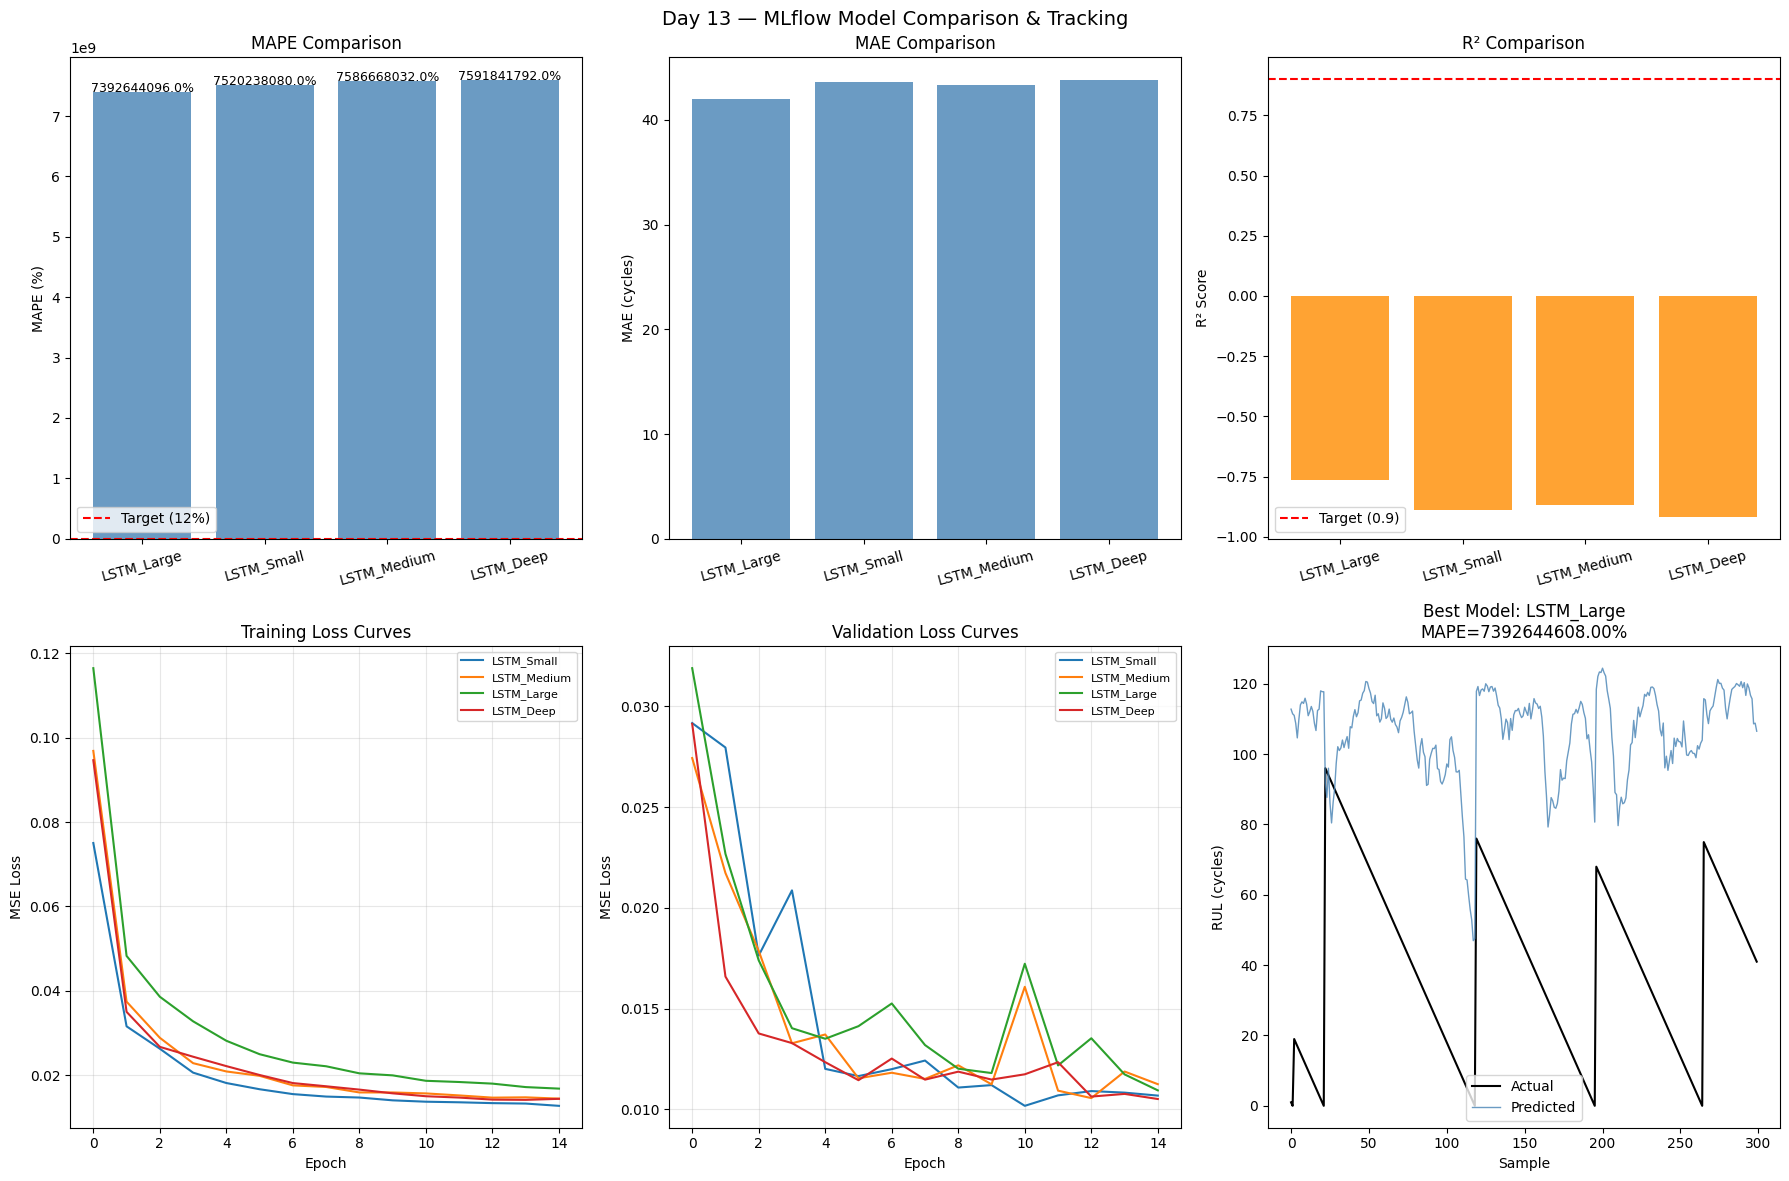

✅ Plots saved!


In [10]:
# ============================================
# CELL 8 - MLflow Comparison Visualizations
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

models  = comparison_df['Model'].tolist()
mapes   = comparison_df['MAPE (%)'].tolist()
maes    = comparison_df['MAE'].tolist()
r2s     = comparison_df['R²'].tolist()
colors  = ['green' if m <= 12 else 'steelblue'
           for m in mapes]

# Plot 1: MAPE Comparison
bars = axes[0,0].bar(models, mapes,
                      color=colors, alpha=0.8)
axes[0,0].axhline(
    12, color='red', linestyle='--',
    label='Target (12%)'
)
axes[0,0].set_title('MAPE Comparison')
axes[0,0].set_ylabel('MAPE (%)')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, mapes):
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', fontsize=9
    )

# Plot 2: MAE Comparison
axes[0,1].bar(models, maes,
              color='steelblue', alpha=0.8)
axes[0,1].set_title('MAE Comparison')
axes[0,1].set_ylabel('MAE (cycles)')
axes[0,1].tick_params(axis='x', rotation=15)

# Plot 3: R² Comparison
axes[0,2].bar(models, r2s,
              color='darkorange', alpha=0.8)
axes[0,2].axhline(
    0.9, color='red', linestyle='--',
    label='Target (0.9)'
)
axes[0,2].set_title('R² Comparison')
axes[0,2].set_ylabel('R² Score')
axes[0,2].legend()
axes[0,2].tick_params(axis='x', rotation=15)

# Plot 4: Training Loss Curves
for r in all_results:
    axes[1,0].plot(
        r['train_losses'],
        label=r['name'],
        linewidth=1.5
    )
axes[1,0].set_title('Training Loss Curves')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('MSE Loss')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Validation Loss Curves
for r in all_results:
    axes[1,1].plot(
        r['val_losses'],
        label=r['name'],
        linewidth=1.5
    )
axes[1,1].set_title('Validation Loss Curves')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('MSE Loss')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Best Model Predictions
best_r = min(all_results, key=lambda x: x['mape'])
sample = min(300, len(best_r['targets']))
axes[1,2].plot(
    best_r['targets'][:sample],
    label='Actual', color='black',
    linewidth=1.5
)
axes[1,2].plot(
    best_r['predictions'][:sample],
    label='Predicted', color='steelblue',
    linewidth=1, alpha=0.8
)
axes[1,2].set_title(
    f'Best Model: {best_r["name"]}\n'
    f'MAPE={best_r["mape"]:.2f}%'
)
axes[1,2].set_xlabel('Sample')
axes[1,2].set_ylabel('RUL (cycles)')
axes[1,2].legend()

plt.suptitle(
    'Day 13 — MLflow Model Comparison & Tracking',
    fontsize=14
)
plt.tight_layout()
plt.savefig(
    '../notebooks/day13_mlflow_comparison.png',
    dpi=150
)
plt.show()
print("✅ Plots saved!")

In [11]:
# ============================================
# CELL 9 - MLflow Summary
# ============================================

print("\n" + "="*55)
print("📊 DAY 13 - MLFLOW TRACKING SUMMARY")
print("="*55)

# List all experiments
experiments = client.search_experiments()
print(f"\n📋 Experiments logged: {len(experiments)}")
for exp in experiments:
    runs = client.search_runs(exp.experiment_id)
    print(f"\n  📊 {exp.name}")
    print(f"     Runs: {len(runs)}")
    for run in runs:
        m    = run.data.metrics
        name = run.data.params.get(
            'model_name', run.info.run_name
        )
        mape = m.get('test_mape', 'N/A')
        mae  = m.get('test_mae',  'N/A')
        print(f"     → {name:20s} "
              f"MAPE={mape if isinstance(mape, str) else f'{mape:.2f}%':8s} "
              f"MAE={mae if isinstance(mae, str) else f'{mae:.4f}':8s}")

print(f"\n💡 View MLflow UI:")
print(f"   Run: mlflow ui --backend-store-uri sqlite:///mlflow.db")
print(f"   Open: http://localhost:5000")
print("\n✅ Day 13 Complete!")


📊 DAY 13 - MLFLOW TRACKING SUMMARY

📋 Experiments logged: 4

  📊 rul_model_comparison
     Runs: 4
     → LSTM_Deep            MAPE=7591841792.00% MAE=43.7817 
     → LSTM_Large           MAPE=7392644608.00% MAE=42.0151 
     → LSTM_Medium          MAPE=7586668032.00% MAE=43.3619 
     → LSTM_Small           MAPE=7520238592.00% MAE=43.5707 

  📊 rul_forecasting
     Runs: 18
     → Hybrid_Ensemble      MAPE=N/A      MAE=N/A     
     → LSTM_Best            MAPE=N/A      MAE=N/A     
     → LSTM_Best            MAPE=N/A      MAE=N/A     
     → LSTM_Attention_Eval  MAPE=7895761408.00% MAE=45.5825 
     → LSTM_Attention_Eval  MAPE=7895761408.00% MAE=45.5825 
     → LSTM_Attention_Main  MAPE=N/A      MAE=N/A     
     → LSTM_Attention_Main  MAPE=N/A      MAE=N/A     
     → LSTM_Attention_Main  MAPE=N/A      MAE=N/A     
     → LSTM_Attention_Main  MAPE=N/A      MAE=N/A     
     → LSTM_Attention_Main  MAPE=N/A      MAE=N/A     
     → LSTM_Attention_Main  MAPE=N/A      MAE=N/A     
    